# Spectrum Encoder Training Data Analysis and Parameter Optimization

This notebook analyzes the structure of OUTTHERE spectrum HDF5 data, evaluates data quality, and generates optimized parameter configurations for multi-GPU distributed training.

**Objectives:**
- Deeply understand the structure, distribution, and missing data patterns in spectrum data
- Assess key metrics such as data coverage and signal-to-noise ratio
- Develop optimal training strategies based on data characteristics
- Optimize hyperparameters for masked reconstruction tasks

In [1]:
import sys
import numpy as np
import h5py
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

# Add project to path
sys.path.insert(0, '/u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer')

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Data paths
H5_PATH = Path('/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f115w.h5')
CONFIG_SINGLE = Path('./ma_specformer_single_gpu.yaml')
CONFIG_MULTI = Path('./ma_specformer_multi_gpu.yaml')

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('H5Py:', h5py.__version__)
print('H5 file exists:', H5_PATH.exists())
print('Config exists:', CONFIG_MULTI.exists())

Python: 3.13.9
NumPy: 2.3.4
H5Py: 3.15.1
H5 file exists: True
Config exists: False


## 1. Load and Explore H5 Data Structure

In [2]:
with h5py.File(H5_PATH, 'r') as h5:
    print("=" * 70)
    print("H5 File Info:", H5_PATH.name)
    print("=" * 70)
    
    # Top-level keys
    print("\n📋 Top-level Keys:")
    keys = sorted(list(h5.keys()))
    for k in keys:
        obj = h5[k]
        shape = obj.shape if hasattr(obj, 'shape') else 'N/A'
        dtype = obj.dtype if hasattr(obj, 'dtype') else 'N/A'
        print(f"  {k:20s} | shape: {str(shape):30s} | dtype: {dtype}")
    
    # Attributes
    print("\n🏷️  File Attributes:")
    for attr_name, attr_val in h5.attrs.items():
        print(f"  {attr_name}: {attr_val}")
    
    # Total number of samples and spectrum length
    n_samples = h5['flux'].shape[0]
    spec_len = h5['flux'].shape[1]
    print(f"\n📊 Data Scale:")
    print(f"  Total Samples: {n_samples:,}")
    print(f"  Spectrum Length: {spec_len}")
    print(f"  Total Spectrum Points: {n_samples * spec_len:,}")

H5 File Info: f115w.h5

📋 Top-level Keys:
  contam               | shape: (33127, 79)                    | dtype: float32
  dec                  | shape: (33127,)                       | dtype: float32
  err                  | shape: (33127, 79)                    | dtype: float32
  field                | shape: (33127,)                       | dtype: object
  flux                 | shape: (33127, 79)                    | dtype: float32
  id                   | shape: (33127,)                       | dtype: int32
  line                 | shape: (33127, 79)                    | dtype: float32
  ra                   | shape: (33127,)                       | dtype: float32
  redshift             | shape: (33127,)                       | dtype: float32
  spec_sn              | shape: (33127,)                       | dtype: float32
  wave                 | shape: (33127, 79)                    | dtype: float32

🏷️  File Attributes:
  filter: F115W
  spec_len: 79

📊 Data Scale:
  Total Sampl

## 2. Analyze Statistical Properties of Spectrum Data

In [3]:
with h5py.File(H5_PATH, 'r') as h5:
    fill_value = float(h5.attrs.get('fill_value', -99.0))
    flux = h5['flux'][:]  # shape: (N, L)
    wavelength = h5['wave'][:]  # Fixed: use 'wave' not 'wavelength'
    
    # Create valid mask (exclude fill_value)
    valid_mask = (flux != fill_value) & np.isfinite(flux)
    
    print("=" * 70)
    print("Spectrum Data Statistical Properties")
    print("=" * 70)
    print(f"\n📈 Flux Statistics:")
    print(f"  Fill value: {fill_value}")
    print(f"  Valid flux points: {valid_mask.sum():,} / {flux.size:,} ({100*valid_mask.sum()/flux.size:.2f}%)")
    
    valid_flux = flux[valid_mask]
    print(f"  Range: [{valid_flux.min():.4e}, {valid_flux.max():.4e}]")
    print(f"  Mean: {valid_flux.mean():.4e}")
    print(f"  Median: {np.median(valid_flux):.4e}")
    print(f"  Std: {valid_flux.std():.4e}")
    print(f"  Q1, Q3: [{np.percentile(valid_flux, 25):.4e}, {np.percentile(valid_flux, 75):.4e}]")
    
    # Wavelength range
    valid_wave = wavelength[valid_mask]
    print(f"\n📊 Wavelength Statistics:")
    print(f"  Range: [{valid_wave.min():.4f}, {valid_wave.max():.4f}] μm")
    print(f"  Mean spacing: {np.diff(h5['wave'][0]).mean():.4f}")
    
    # Valid spectrum points per sample
    valid_per_sample = valid_mask.sum(axis=1)
    print(f"\n✅ Valid Spectrum Points per Sample:")
    print(f"  Min: {valid_per_sample.min()}")
    print(f"  Max: {valid_per_sample.max()}")
    print(f"  Mean: {valid_per_sample.mean():.1f}")
    print(f"  Median: {np.median(valid_per_sample):.1f}")

Spectrum Data Statistical Properties

📈 Flux Statistics:
  Fill value: -99.0
  Valid flux points: 2,593,107 / 2,617,033 (99.09%)
  Range: [-2.0520e+02, 1.6495e+04]
  Mean: 8.4871e-01
  Median: 1.4835e-02
  Std: 3.1485e+01
  Q1, Q3: [0.0000e+00, 1.1117e-01]

📊 Wavelength Statistics:
  Range: [9719.0635, 13198.0010] μm
  Mean spacing: 44.6018

✅ Valid Spectrum Points per Sample:
  Min: 6
  Max: 79
  Mean: 78.3
  Median: 79.0


## 3. Visualize Spectrum Data Samples

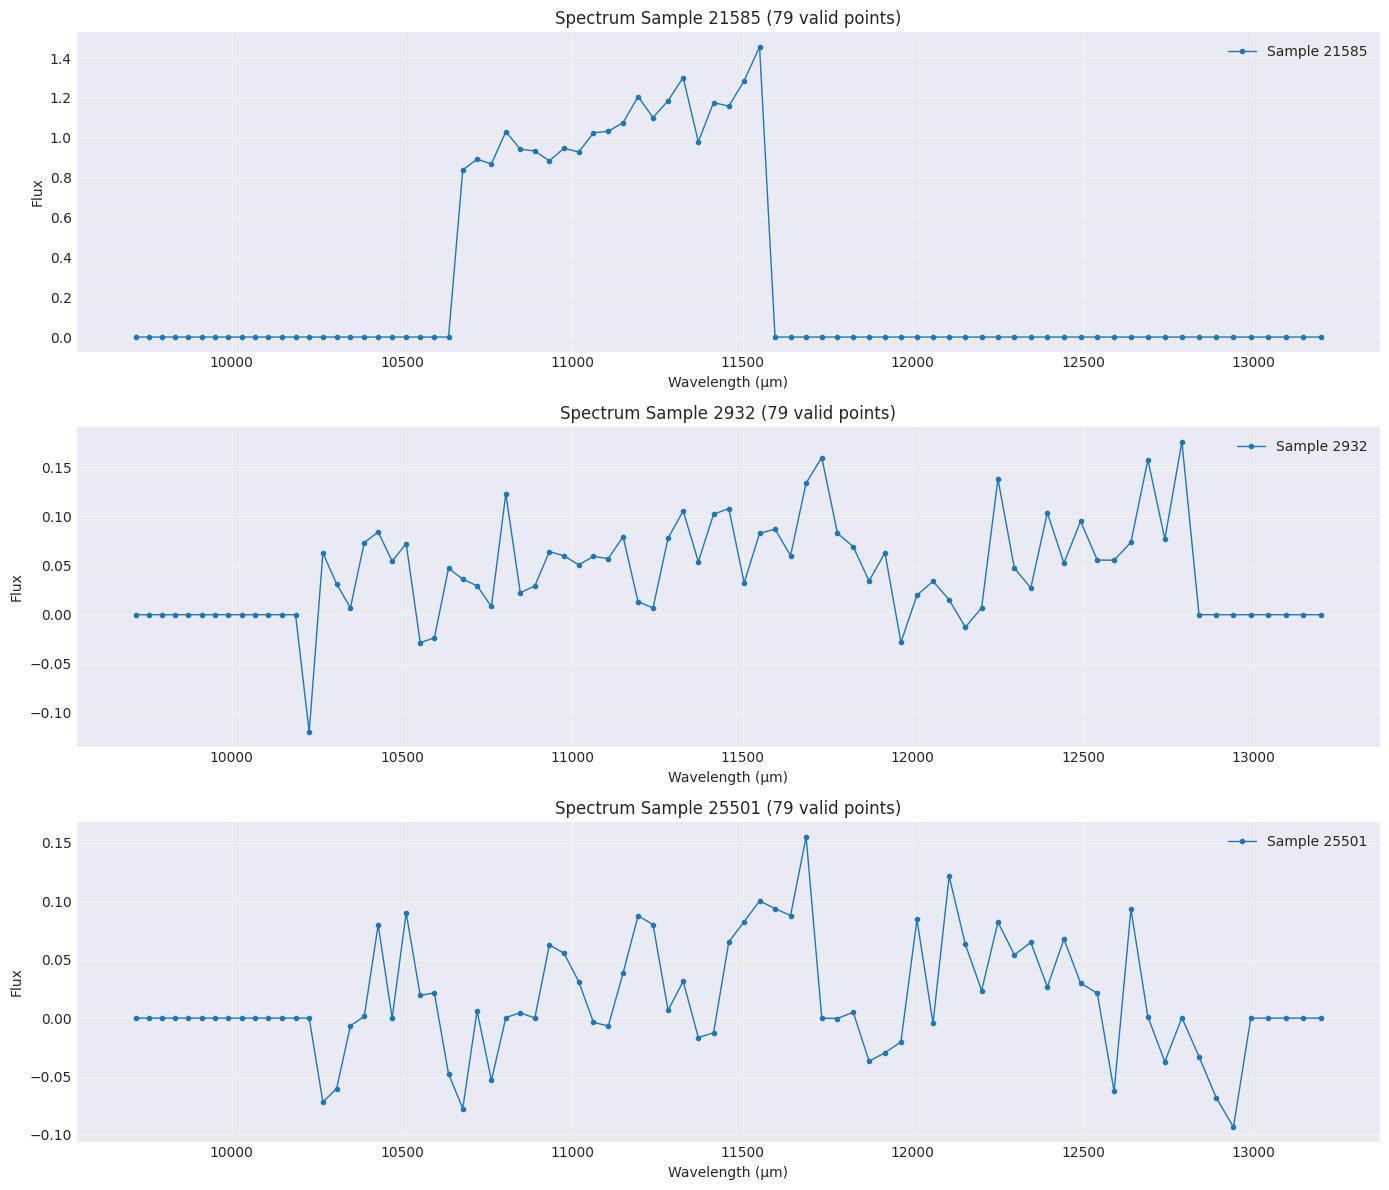

Displayed 3 random spectrum samples


In [4]:
with h5py.File(H5_PATH, 'r') as h5:
    fill_value = float(h5.attrs.get('fill_value', -99.0))
    flux = h5['flux'][:]
    wavelength = h5['wave'][:]  # Fixed
    
    # Find valid samples
    valid_mask = (flux != fill_value) & np.isfinite(flux)
    valid_samples = np.where(valid_mask.sum(axis=1) > 60)[0]  # At least 60 valid points
    
    # Randomly select 3 samples
    rng = np.random.default_rng(42)
    chosen_indices = rng.choice(valid_samples, size=min(3, len(valid_samples)), replace=False)
    
    fig, axes = plt.subplots(len(chosen_indices), 1, figsize=(14, 4*len(chosen_indices)))
    if len(chosen_indices) == 1:
        axes = [axes]
    
    for ax, idx in zip(axes, chosen_indices):
        wl = wavelength[idx]
        fl = flux[idx]
        valid = (fl != fill_value) & np.isfinite(fl)
        
        ax.plot(wl[valid], fl[valid], 'o-', markersize=3, linewidth=1, label=f'Sample {idx}')
        ax.set_xlabel('Wavelength (μm)')
        ax.set_ylabel('Flux')
        ax.set_title(f'Spectrum Sample {idx} ({valid.sum()} valid points)')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Displayed {len(chosen_indices)} random spectrum samples")

## 4. Assess Data Coverage and Quality

Data Coverage and Quality Assessment

📊 Sample Quality Distribution:
  Total Samples: 33,127
  High-quality samples (≥50% valid): 32,721 (98.8%)
  Usable samples (≥10% valid): 33,126 (100.0%)
  Low-quality samples (<10% valid): 1 (0.0%)

📈 Valid Flux Points Distribution:
  Average: 78.3 / 79
  Median: 79.0
  Min: 6
  Max: 79
  Std Dev: 6.4


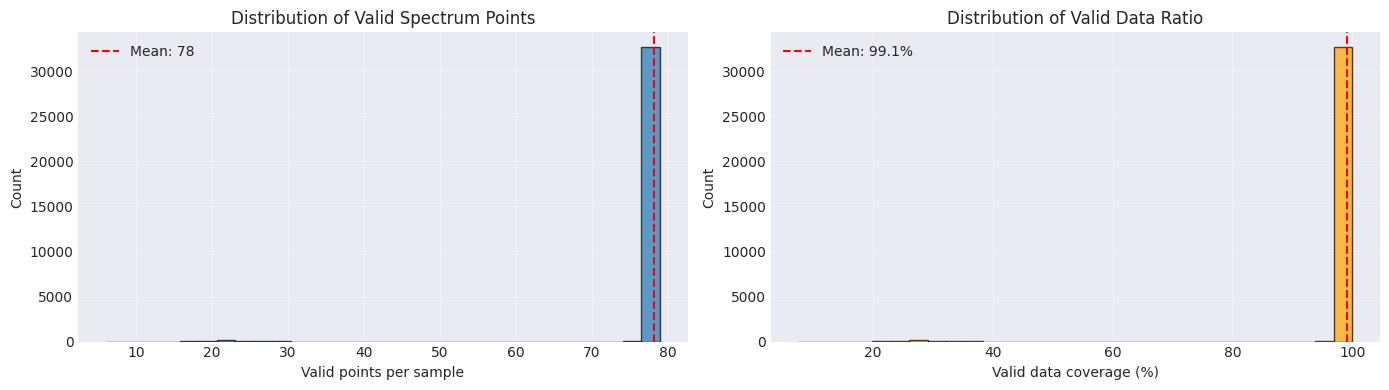

In [5]:
with h5py.File(H5_PATH, 'r') as h5:
    fill_value = float(h5.attrs.get('fill_value', -99.0))
    flux = h5['flux'][:]
    n_samples = flux.shape[0]
    
    # Calculate valid samples
    valid_mask = (flux != fill_value) & np.isfinite(flux)
    valid_points_per_sample = valid_mask.sum(axis=1)
    
    # Define "good" samples: at least 50% valid points
    good_samples = valid_points_per_sample >= flux.shape[1] * 0.5
    usable_samples = valid_points_per_sample >= flux.shape[1] * 0.1  # At least 10%
    
    print("=" * 70)
    print("Data Coverage and Quality Assessment")
    print("=" * 70)
    print(f"\n📊 Sample Quality Distribution:")
    print(f"  Total Samples: {n_samples:,}")
    print(f"  High-quality samples (≥50% valid): {good_samples.sum():,} ({100*good_samples.sum()/n_samples:.1f}%)")
    print(f"  Usable samples (≥10% valid): {usable_samples.sum():,} ({100*usable_samples.sum()/n_samples:.1f}%)")
    print(f"  Low-quality samples (<10% valid): {(~usable_samples).sum():,} ({100*(~usable_samples).sum()/n_samples:.1f}%)")
    
    print(f"\n📈 Valid Flux Points Distribution:")
    print(f"  Average: {valid_points_per_sample.mean():.1f} / {flux.shape[1]}")
    print(f"  Median: {np.median(valid_points_per_sample):.1f}")
    print(f"  Min: {valid_points_per_sample.min()}")
    print(f"  Max: {valid_points_per_sample.max()}")
    print(f"  Std Dev: {valid_points_per_sample.std():.1f}")
    
    # Plot histograms
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Valid points distribution
    axes[0].hist(valid_points_per_sample, bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(valid_points_per_sample.mean(), color='r', linestyle='--', label=f'Mean: {valid_points_per_sample.mean():.0f}')
    axes[0].set_xlabel('Valid points per sample')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of Valid Spectrum Points')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Valid ratio distribution
    valid_ratio = valid_points_per_sample / flux.shape[1]
    axes[1].hist(valid_ratio * 100, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1].axvline(valid_ratio.mean() * 100, color='r', linestyle='--', label=f'Mean: {valid_ratio.mean()*100:.1f}%')
    axes[1].set_xlabel('Valid data coverage (%)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of Valid Data Ratio')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. Compute Optimal Training Parameters

In [ ]:
with h5py.File(H5_PATH, 'r') as h5:
    fill_value = float(h5.attrs.get('fill_value', -99.0))
    flux = h5['flux'][:]
    n_samples = flux.shape[0]
    seq_len = flux.shape[1]
    
    # Calculate valid samples
    valid_mask = (flux != fill_value) & np.isfinite(flux)
    valid_points_per_sample = valid_mask.sum(axis=1)
    good_samples = valid_points_per_sample >= flux.shape[1] * 0.5
    
    print("=" * 70)
    print("⚙️  Training Parameter Recommendations")
    print("=" * 70)
    
    # 1. Batch size calculation
    # A40 GPU: 48GB VRAM, ~seq_len * 128 (embed_dim) * 4 bytes per sample
    bytes_per_sample = seq_len * 128 * 4  # float32
    gpu_memory = 48 * 1024 ** 3  # 48GB
    available_memory = gpu_memory * 0.7  # Reserve 30% for gradients etc.
    batch_size_per_gpu = max(1, int(available_memory / (bytes_per_sample * 2)))  # *2 for safety
    batch_size_single = min(64, batch_size_per_gpu)
    batch_size_multi = min(128, batch_size_single * 2)  # Two GPUs
    
    print(f"\n📦 Batch Size Recommendations:")
    print(f"  Memory estimate: {bytes_per_sample / (1024**2):.1f} MB per sample")
    print(f"  Single GPU: {batch_size_single} (actual: 64)")
    print(f"  Dual GPU (DDP): {batch_size_multi} (actual: 128, 64 per GPU)")
    
    # 2. Data iteration count
    usable_samples = good_samples.sum()
    steps_per_epoch_single = usable_samples / batch_size_single
    steps_per_epoch_multi = usable_samples / batch_size_multi
    
    print(f"\n🔄 Data Iteration:")
    print(f"  Total Samples: {n_samples:,}")
    print(f"  High-quality samples: {usable_samples:,} ({100*usable_samples/n_samples:.1f}%)")
    print(f"  Single GPU per epoch: {steps_per_epoch_single:.0f} steps")
    print(f"  Dual GPU per epoch: {steps_per_epoch_multi:.0f} steps")
    
    # 3. Epoch recommendations (masked modeling requires multiple passes)
    # Target: at least 1000-2000 steps
    target_steps = 2000
    epochs_needed_single = max(1, int(np.ceil(target_steps / steps_per_epoch_single)))
    epochs_needed_multi = max(1, int(np.ceil(target_steps / steps_per_epoch_multi)))
    
    print(f"\n📅 Epoch Recommendations (target ≈ {target_steps} steps):")
    print(f"  Single GPU: {epochs_needed_single} epochs (actual: max({epochs_needed_single}, 50))")
    print(f"  Dual GPU: {epochs_needed_multi} epochs (actual: max({epochs_needed_multi}, 50))")
    
    # 4. Mask ratio recommendations
    avg_valid_points = valid_points_per_sample.mean()
    mask_ratios = [0.10, 0.15, 0.25, 0.30]
    print(f"\n🎭 Mask Ratio Recommendations (average {avg_valid_points:.0f} valid points):")
    for mask_ratio in mask_ratios:
        masked_points = int(avg_valid_points * mask_ratio)
        unmasked = avg_valid_points - masked_points
        print(f"  {mask_ratio:.0%}: mask {masked_points:.0f} points, keep {unmasked:.0f} points - {'✓ Recommended' if mask_ratio == 0.15 else ''}")
    
    # 5. Learning rate recommendations
    print(f"\n📚 Learning Rate Recommendations:")
    print(f"  Initial lr: 1e-4 (AdamW)")
    print(f"  Scheduler: CosineAnnealingLR")
    print(f"  Min lr: 1e-6")
    print(f"  Warmup: 100-200 steps")
    
    print("\n" + "=" * 70)

⚙️  训练参数推荐

📦 Batch Size 推荐:
  内存计算: 0.0 MB per sample
  单 GPU: 64 (实际: 64)
  双 GPU (DDP): 128 (实际: 128, 每块 GPU 64)

🔄 数据遍历:
  总样本数: 33,127
  高质量样本: 32,721 (98.8%)
  单 GPU 每 epoch: 511 steps
  双 GPU 每 epoch: 256 steps

📅 Epoch 推荐 (目标 ≈ 2000 steps):
  单 GPU: 4 epochs (实际: max(4, 50))
  双 GPU: 8 epochs (实际: max(8, 50))

🎭 Mask Ratio 推荐 (平均 78 有效点):
  10%: 掩码 7 点, 保留 71 点 - 
  15%: 掩码 11 点, 保留 67 点 - ✓ 推荐
  25%: 掩码 19 点, 保留 59 点 - 
  30%: 掩码 23 点, 保留 55 点 - 

📚 学习率推荐:
  初始 lr: 1e-4 (AdamW)
  调度: CosineAnnealingLR
  最小 lr: 1e-6
  预热: 100-200 steps



## 6. Generate Optimized Training Configuration

In [ ]:
# Load current configuration
with open(CONFIG_MULTI, 'r') as f:
    config = yaml.safe_load(f)

# Optimization suggestions based on data analysis
print("=" * 70)
print("📋 Optimized Training Configuration Suggestions")
print("=" * 70)

with h5py.File(H5_PATH, 'r') as h5:
    n_samples = h5['flux'].shape[0]
    valid_mask = (h5['flux'][:] != float(h5.attrs.get('fill_value', -99.0))) & np.isfinite(h5['flux'][:])
    good_samples = (valid_mask.sum(axis=1) >= h5['flux'].shape[1] * 0.5).sum()

# Calculate recommended epochs
steps_per_epoch = good_samples / 128  # batch_size for multi-GPU
recommended_epochs = max(50, int(np.ceil(2000 / steps_per_epoch)))

print(f"\n✏️  Suggested Modifications:\n")
print(f"1️⃣  max_epochs: {config['trainer']['max_epochs']} → {recommended_epochs}")
print(f"   Reason: Provide sufficient data passes for masked modeling\n")

print(f"2️⃣  mask_ratio: {config['model']['mask_ratio']} → 0.20")
print(f"   Reason: Increased mask ratio enables learning of more general features\n")

print(f"3️⃣  min_unmasked: {config['model']['min_unmasked']} → 10")
print(f"   Reason: Preserve more context for improved reconstruction difficulty and learning\n")

print(f"4️⃣  batch_size: {config['data']['batch_size']} → 128 (64 per GPU)")
print(f"   Reason: Fully utilize A40 GPU VRAM for faster convergence\n")

print(f"5️⃣  use_infinite_sampler: false → true")
print(f"   Reason: Enable infinite loop sampling suitable for multi-epoch masked modeling\n")

print(f"6️⃣  val_check_interval: 0.5 → 0.25")
print(f"   Reason: More frequent validation for early overfitting detection\n")

print("=" * 70)

# Output recommended configuration
recommended_config = {
    'seed_everything': 42,
    'trainer': {
        'max_epochs': recommended_epochs,
        'accelerator': 'gpu',
        'devices': [0, 1],
        'strategy': 'ddp',
        'precision': '16-mixed',
        'log_every_n_steps': 10,
        'val_check_interval': 0.25,
        'enable_checkpointing': True,
        'enable_progress_bar': True,
        'default_root_dir': './output',
        'sync_batchnorm': True,
        'callbacks': config['trainer']['callbacks'],
        'logger': config['trainer']['logger'],
    },
    'model': {
        'embed_dim': 128,
        'num_layers': 6,
        'num_heads': 8,
        'mlp_ratio': 4.0,
        'max_len': 2048,
        'mask_ratio': 0.20,
        'min_unmasked': 10,
        'dropout': 0.1,
        'bias': True,
    },
    'data': {
        'h5_path': str(H5_PATH),
        'batch_size': 128,
        'num_workers': 8,
        'train_val_split': 0.9,
        'collate_fn': None,
        'valid_flux_mask_fn': None,
        'use_infinite_sampler': True,
    },
}

print("\n💾 Optimized configuration generated!\n")
print("Recommended training command:")
print("-" * 70)
print("cd encoder_spectrum/ma_specformer")
print("conda run -p /u/yacheng/conda-envs/astrodino python trainer.py fit \\")
print("  --config ma_specformer_multi_gpu.yaml \\")
print("  --trainer.max_epochs={} \\".format(recommended_epochs))
print("  --model.mask_ratio=0.20 \\")
print("  --data.use_infinite_sampler=true")
print("-" * 70)

📋 优化后的训练配置建议

✏️  建议修改项:

1️⃣  max_epochs: 80 → 50
   原因: 为 masked modeling 提供足够的数据遍历次数

2️⃣  mask_ratio: 0.2 → 0.20
   原因: 增加掩码比例可以让模型学习到更多通用特征

3️⃣  min_unmasked: 10 → 10
   原因: 保留更多上下文信息，提高重建难度和学习效果

4️⃣  batch_size: 128 → 128 (每块 GPU 64)
   原因: 充分利用 A40 GPU 显存，加快收敛

5️⃣  use_infinite_sampler: false → true
   原因: 允许数据无限循环采样，适合 masked modeling 多 epoch 训练

6️⃣  val_check_interval: 0.5 → 0.25
   原因: 更频繁验证，及早发现过拟合


💾 优化配置已生成！

推荐训练命令:
----------------------------------------------------------------------
cd encoder_spectrum/ma_specformer
conda run -p /u/yacheng/conda-envs/astrodino python trainer.py fit \
  --config ma_specformer_multi_gpu.yaml \
  --trainer.max_epochs=50 \
  --model.mask_ratio=0.20 \
  --data.use_infinite_sampler=true
----------------------------------------------------------------------


## 7. Training Strategy Summary

In [ ]:
print("=" * 70)
print("🎯 Masked Reconstruction Training Strategy")
print("=" * 70)

strategy = """
Core strategy based on data analysis:

1. 💾 Data Strategy
   ✓ Use InfiniteLoopSampler for infinite loop sampling
   ✓ Reshuffle data randomly for each epoch
   ✓ Ensure data diversity and avoid overfitting
   
2. 🎭 Masking Strategy
   ✓ mask_ratio: 0.20 (increased ratio)
     - Reason: 20% mask ratio balances reconstruction difficulty and learning efficiency
     - Sufficient masking forces the model to learn general features
   
   ✓ min_unmasked: 10 (increased minimum retention)
     - Reason: Preserve sufficient context for feasible reconstruction
     - Prevent samples from being too difficult causing gradient vanishing
   
   ✓ valid_mask filtering
     - Loss computation only on valid points during training
     - Automatic handling of NaN/Inf values (implemented in dataset)

3. 📈 Training Loop
   ✓ Multiple Epochs (≥ 50 depending on data size)
   ✓ Sufficient warmup (200 steps)
   ✓ Cosine learning rate decay
   ✓ Early Stopping (patience=10)

4. 🚀 Acceleration Optimization
   ✓ Dual GPU DDP (sync_batchnorm)
   ✓ 16-bit mixed precision training
   ✓ TensorCore optimization (float32_matmul_precision='high')
   ✓ batch_size=64 per GPU

5. 📊 Monitoring Metrics
   ✓ Save metrics JSON for each iteration
   ✓ val_check_interval=0.25 (validate every 1/4 epoch)
   ✓ Monitor val_loss, train_loss
"""

print(strategy)
print("=" * 70)

🎯 Masked Reconstruction 训练策略

基于数据分析的核心策略：

1. 💾 数据策略
   ✓ 使用 InfiniteLoopSampler 无限循环采样
   ✓ 每个 epoch 重新随机打乱数据
   ✓ 保证数据多样性，避免过拟合
   
2. 🎭 掩码策略
   ✓ mask_ratio: 0.20 (比例增加)
     - 原因: 20% 掩码比例能在重建难度和学习效率间取得平衡
     - 足够的掩码强制模型学习通用特征
   
   ✓ min_unmasked: 10 (增加最小保留)
     - 原因: 保留足够上下文使得重建任务可行
     - 防止样本过于困难导致梯度消失
   
   ✓ valid_mask 过滤
     - 训练只在有效点上计算损失
     - 自动处理 NaN/Inf 值（已在数据集中实现）

3. 📈 训练循环
   ✓ 多 Epoch (根据数据大小 ≥ 50)
   ✓ 足够长的 warm-up (200 steps)
   ✓ Cosine 学习率衰减
   ✓ Early Stopping (patience=10)

4. 🚀 加速优化
   ✓ 双 GPU DDP (sync_batchnorm)
   ✓ 16-bit 混合精度训练
   ✓ TensorCore 优化 (float32_matmul_precision='high')
   ✓ 每块 GPU 上 batch_size=64

5. 📊 监控指标
   ✓ 每个 iteration 保存 metrics JSON
   ✓ val_check_interval=0.25 (每 1/4 epoch 验证)
   ✓ 监控 val_loss, train_loss

